In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [2]:
import jax
import pickle
import numpy as np
from aim_resolve import OptimizeKLConfig, SetupKLConfig, SignalGrid, get_builders, plot_arrays, map_signal

jax.config.update("jax_enable_x64", True)

jwst not installed. Some JWST functions will not work.
shapely not installed. Some JWST functions will not work.


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def box_markers(cfg, ps_map, grid, it):
    import numpy as np
    from aim_resolve import draw_boxes

    px, py = np.argwhere(ps_map > 0).T
    ps_mrk = dict(x=px, y=py, s=10, c='white', marker='+')
    box_map = draw_boxes(cfg.sections, grid, it)
    ox, oy = np.argwhere(box_map > 0).T
    oj_mrk = dict(x=ox, y=oy, s=0.1, c='white', marker=',')
    
    return dict(ps_mrk=ps_mrk, oj_mrk=oj_mrk)

In [4]:
dir = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_1z_b'

mf_rec = '3_rec_2z_4f'
mf_it = 5

ARCMIN2RAD = np.pi / 60 / 180
AS2RAD = ARCMIN2RAD / 60
CONV_FACTOR = 1000 * AS2RAD**2


opt_yml = f'{dir}/opt/{mf_rec}/opt.yml'
print('load:', opt_yml)

optim_cfg = OptimizeKLConfig.from_file(opt_yml, get_builders, 'major')
optim_cfg.sections['data.0']['fname'] = '/Users/rf/Development/data/eso_986-1137mhz.npz'

sky_mf = optim_cfg.instantiate_sec(f'sky.{mf_it}')
print('sky components:', [c.prefix for c in sky_mf.models])

with open(f'{dir}/opt/{mf_rec}/last.pkl', "rb") as f:
    samples_mf, *_ = pickle.load(f)
print('samples:', len(samples_mf))

setup_cfg = SetupKLConfig.from_file(opt_yml)
sky_ps = sky_mf.points[0]
ps_map = map_signal(sky_ps.points.grid, sky_ps.grid)(np.ones(sky_ps.shape)).sum(axis=0)
markers_mf = box_markers(setup_cfg, ps_map, sky_mf.grid, mf_it)
print('markers:', [f'{k}: {len(v["x"])}' for k, v in markers_mf.items()])

load: /Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_1f_1024_1z_b/opt/3_rec_2z_4f/opt.yml
sky components: ['bg.5', 'p0.5', 'o0.5', 'o1.5', 'o2.5', 't0.5']
samples: 4
markers: ['ps_mrk: 156', 'oj_mrk: 35550']


In [5]:
min_mf = 2.5e-3
max_mf = np.max(samples_mf.mean(sky_mf.ref_freq_model) * CONV_FACTOR)
print('vmin:', min_mf, '\nvmax:', max_mf)

plot_dict = dict(
    name = None,
    odir = None,
    norm = 'log',
    vmin = min_mf,
    vmax = max_mf,
    cmap = 'inferno',
    cbar = False,
    ticks = 0,
    dpi=300,
)

vmin: 0.0025 
vmax: 5.070727680217303


plotting ...


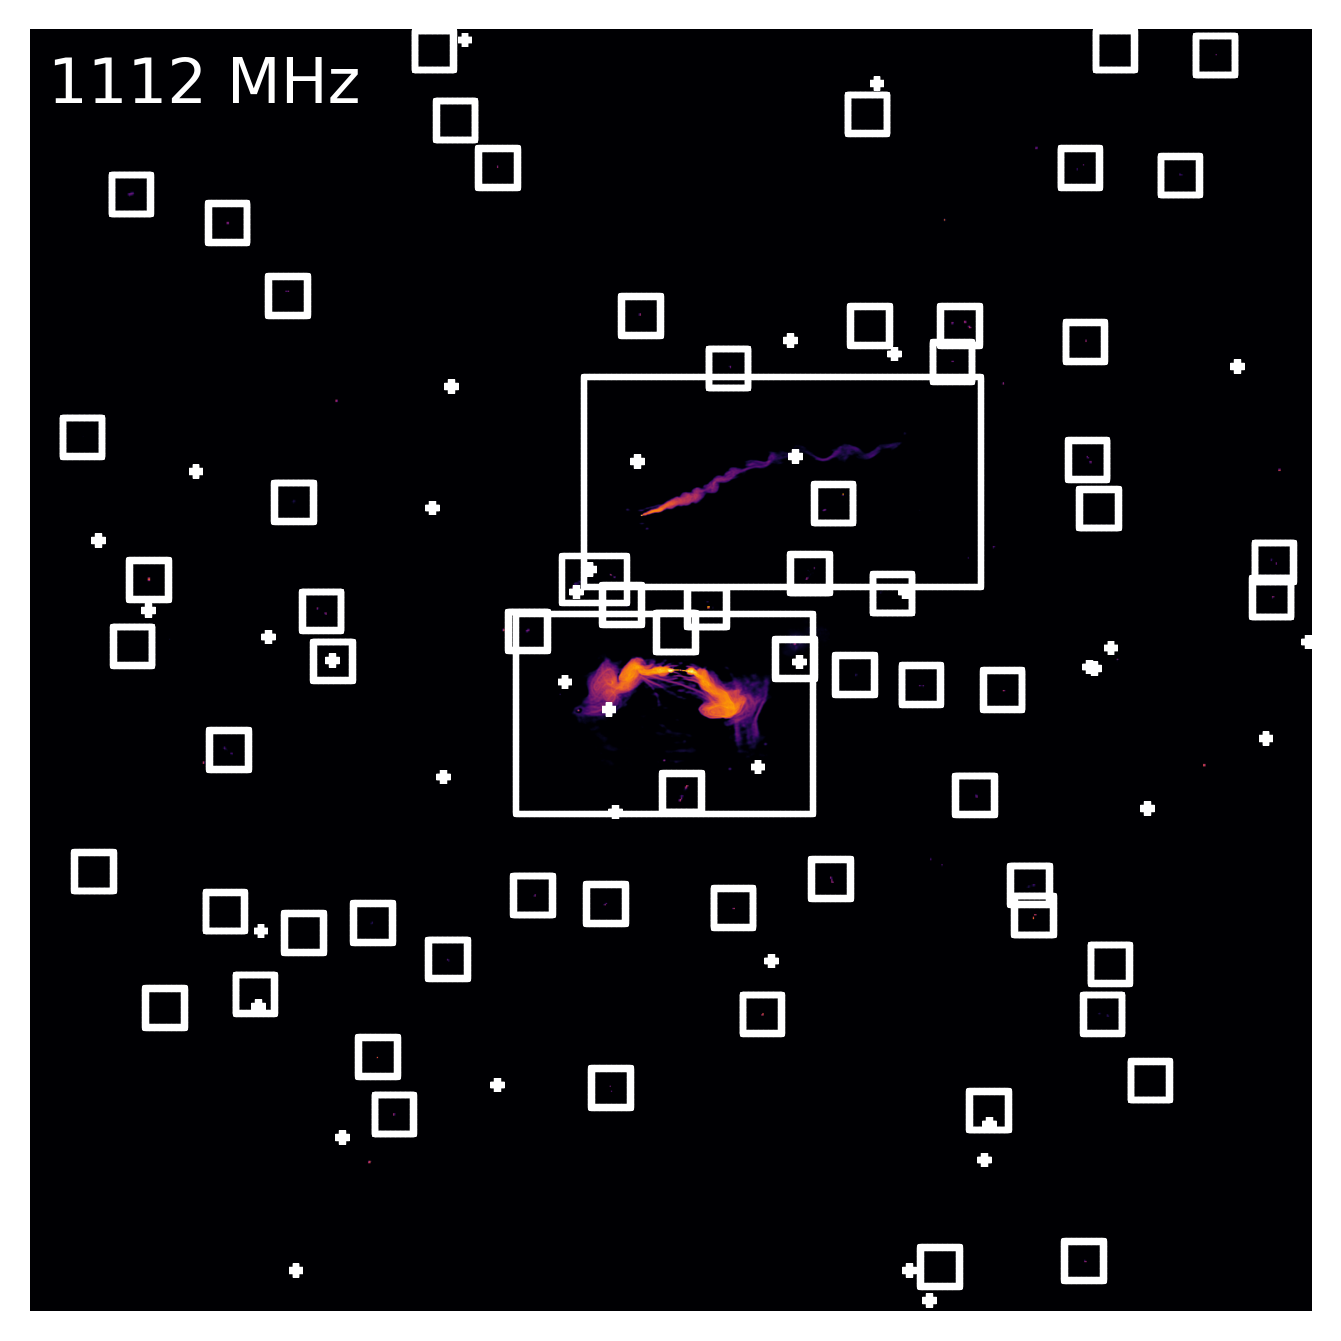

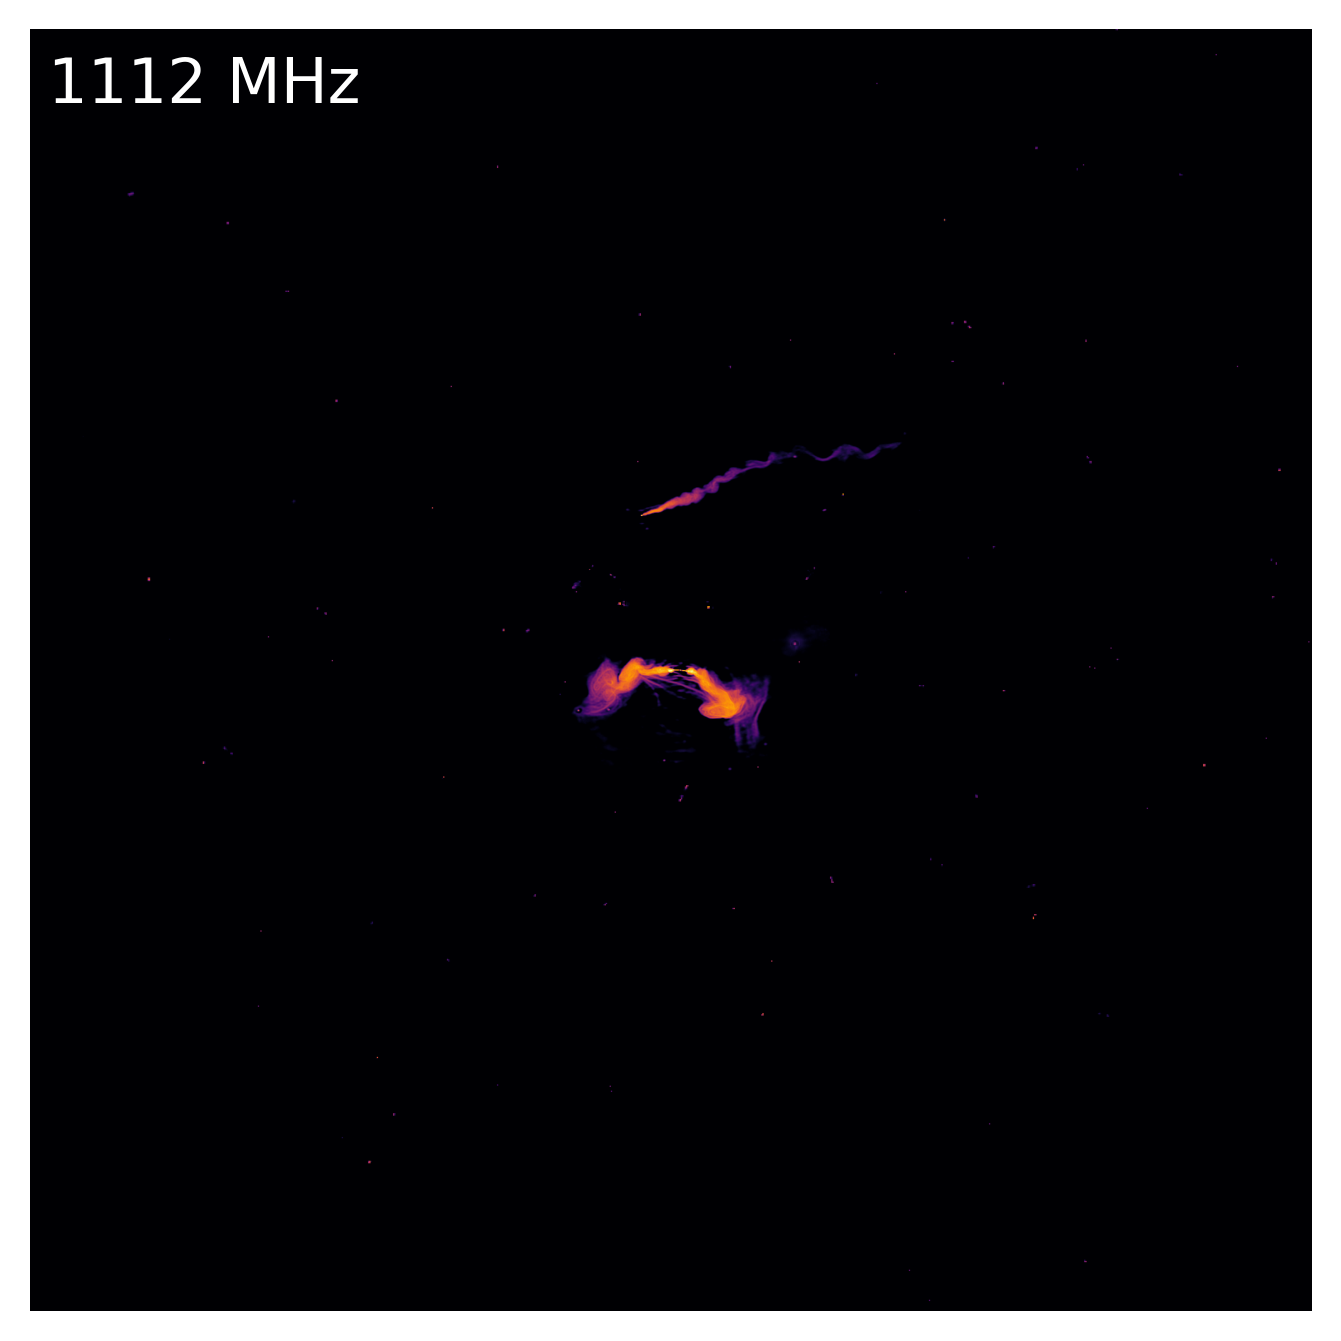

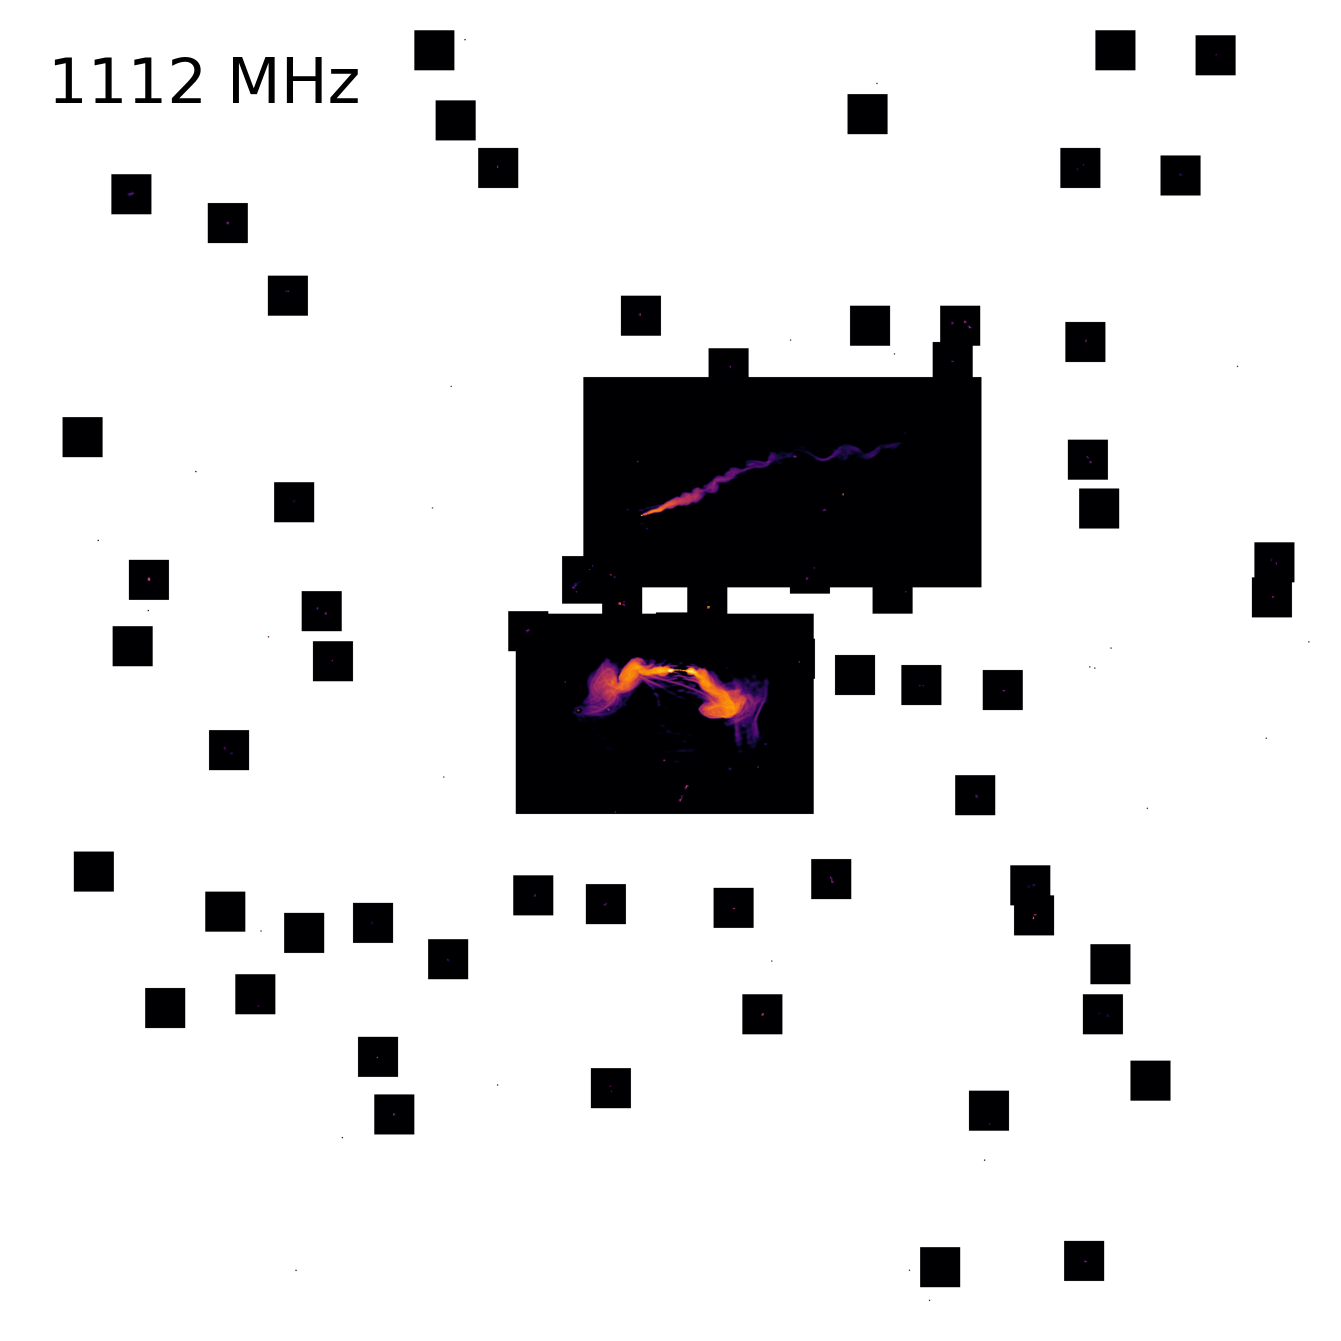

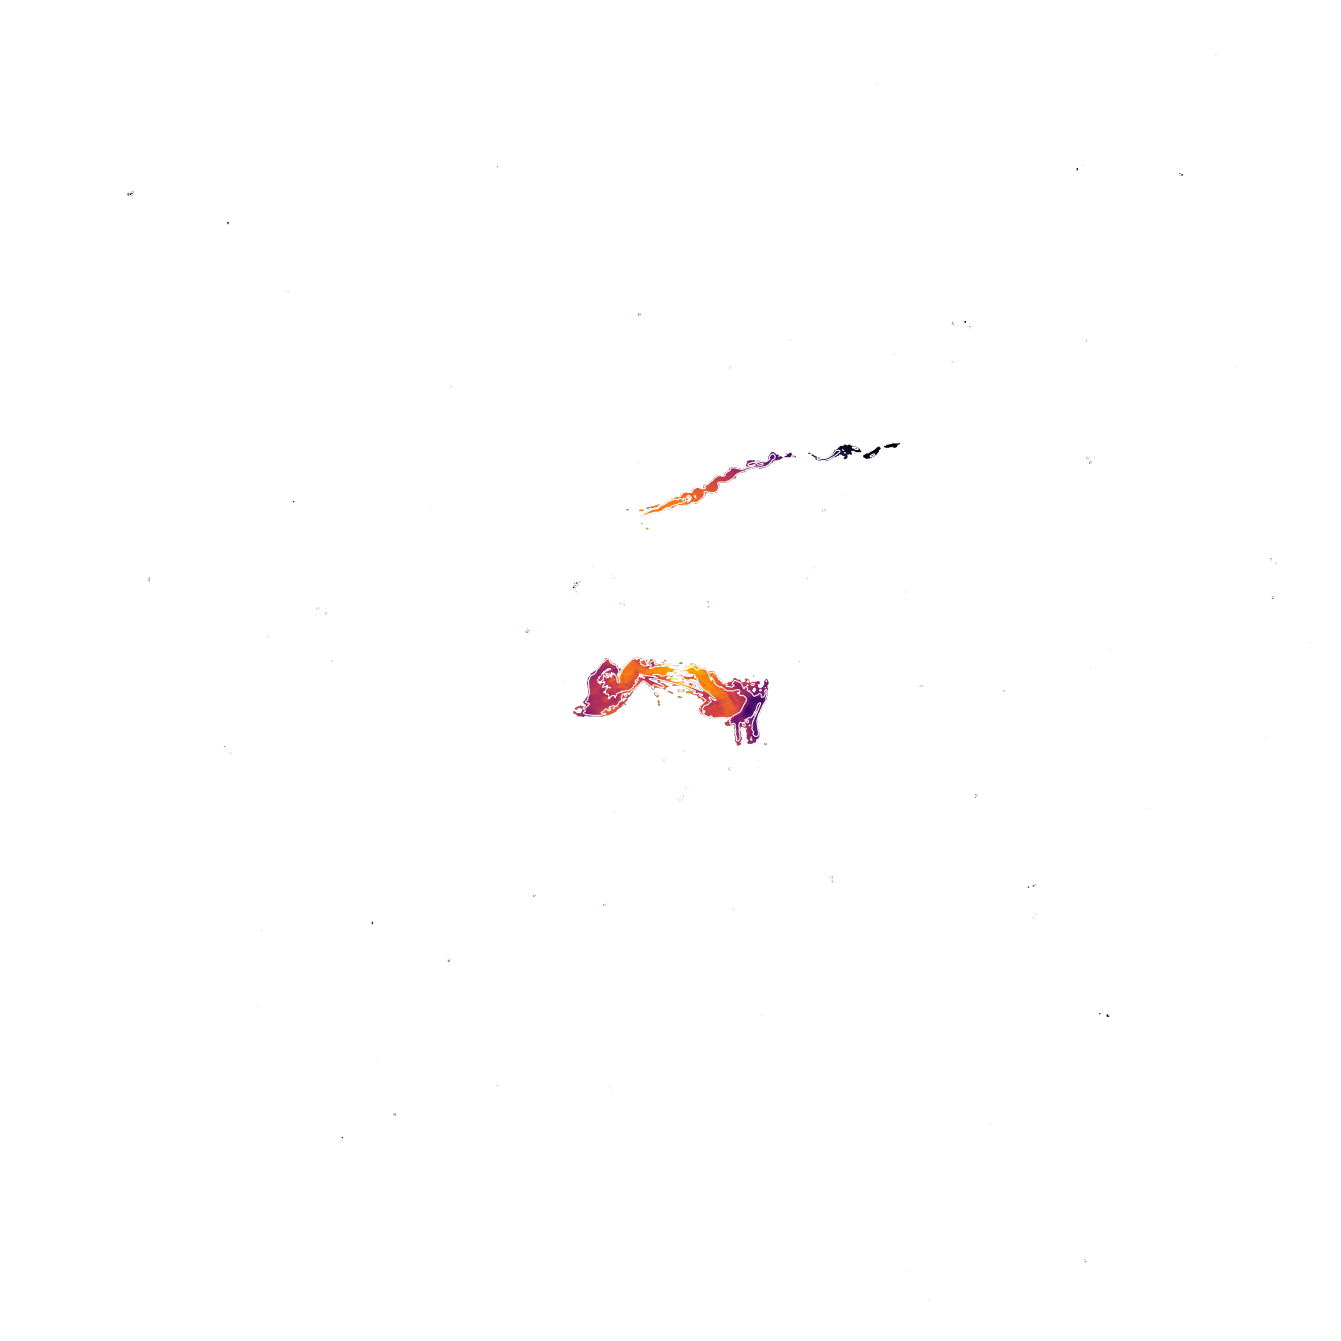

In [11]:
sky_ref_mf = samples_mf.mean(sky_mf.ref_freq_model) * CONV_FACTOR

pot_ref_mf = samples_mf.mean(sky_mf.points_and_objects.ref_freq_model) * CONV_FACTOR

pot_alpha = samples_mf.mean(sky_mf.points_and_objects.spectral_index)
pot_alpha = np.where(pot_ref_mf > 5e-3, pot_alpha, np.nan)
amin, amax = -1, 3

contours = {'array': sky_ref_mf, 'colors': 'white', 'levels': [1e-2, 1e-1], 'linewidths': 0.25}

print('plotting ...')
plot_arrays(
    array = sky_ref_mf, 
    marker = markers_mf,
    callback = lambda fig, ax: fig.text(0.085, 0.90, '1112 MHz', fontsize=15, c='white'),
    **plot_dict,
)
plot_arrays(
    array = sky_ref_mf, 
    callback = lambda fig, ax: fig.text(0.085, 0.90, '1112 MHz', fontsize=15, c='white'),
    **plot_dict,
)
plot_arrays(
    array = pot_ref_mf, 
    callback = lambda fig, ax: fig.text(0.085, 0.90, '1112 MHz', fontsize=15, c='black'),
    **plot_dict,
)
plot_arrays(
    array = pot_alpha, 
    # callback = lambda fig, ax: fig.text(0.085, 0.90, 'Spectral Index', fontsize=15, c='black'),
    contour = contours,
    **plot_dict | dict(vmin=amin, vmax=amax, norm='linear'),
)

plotting ...


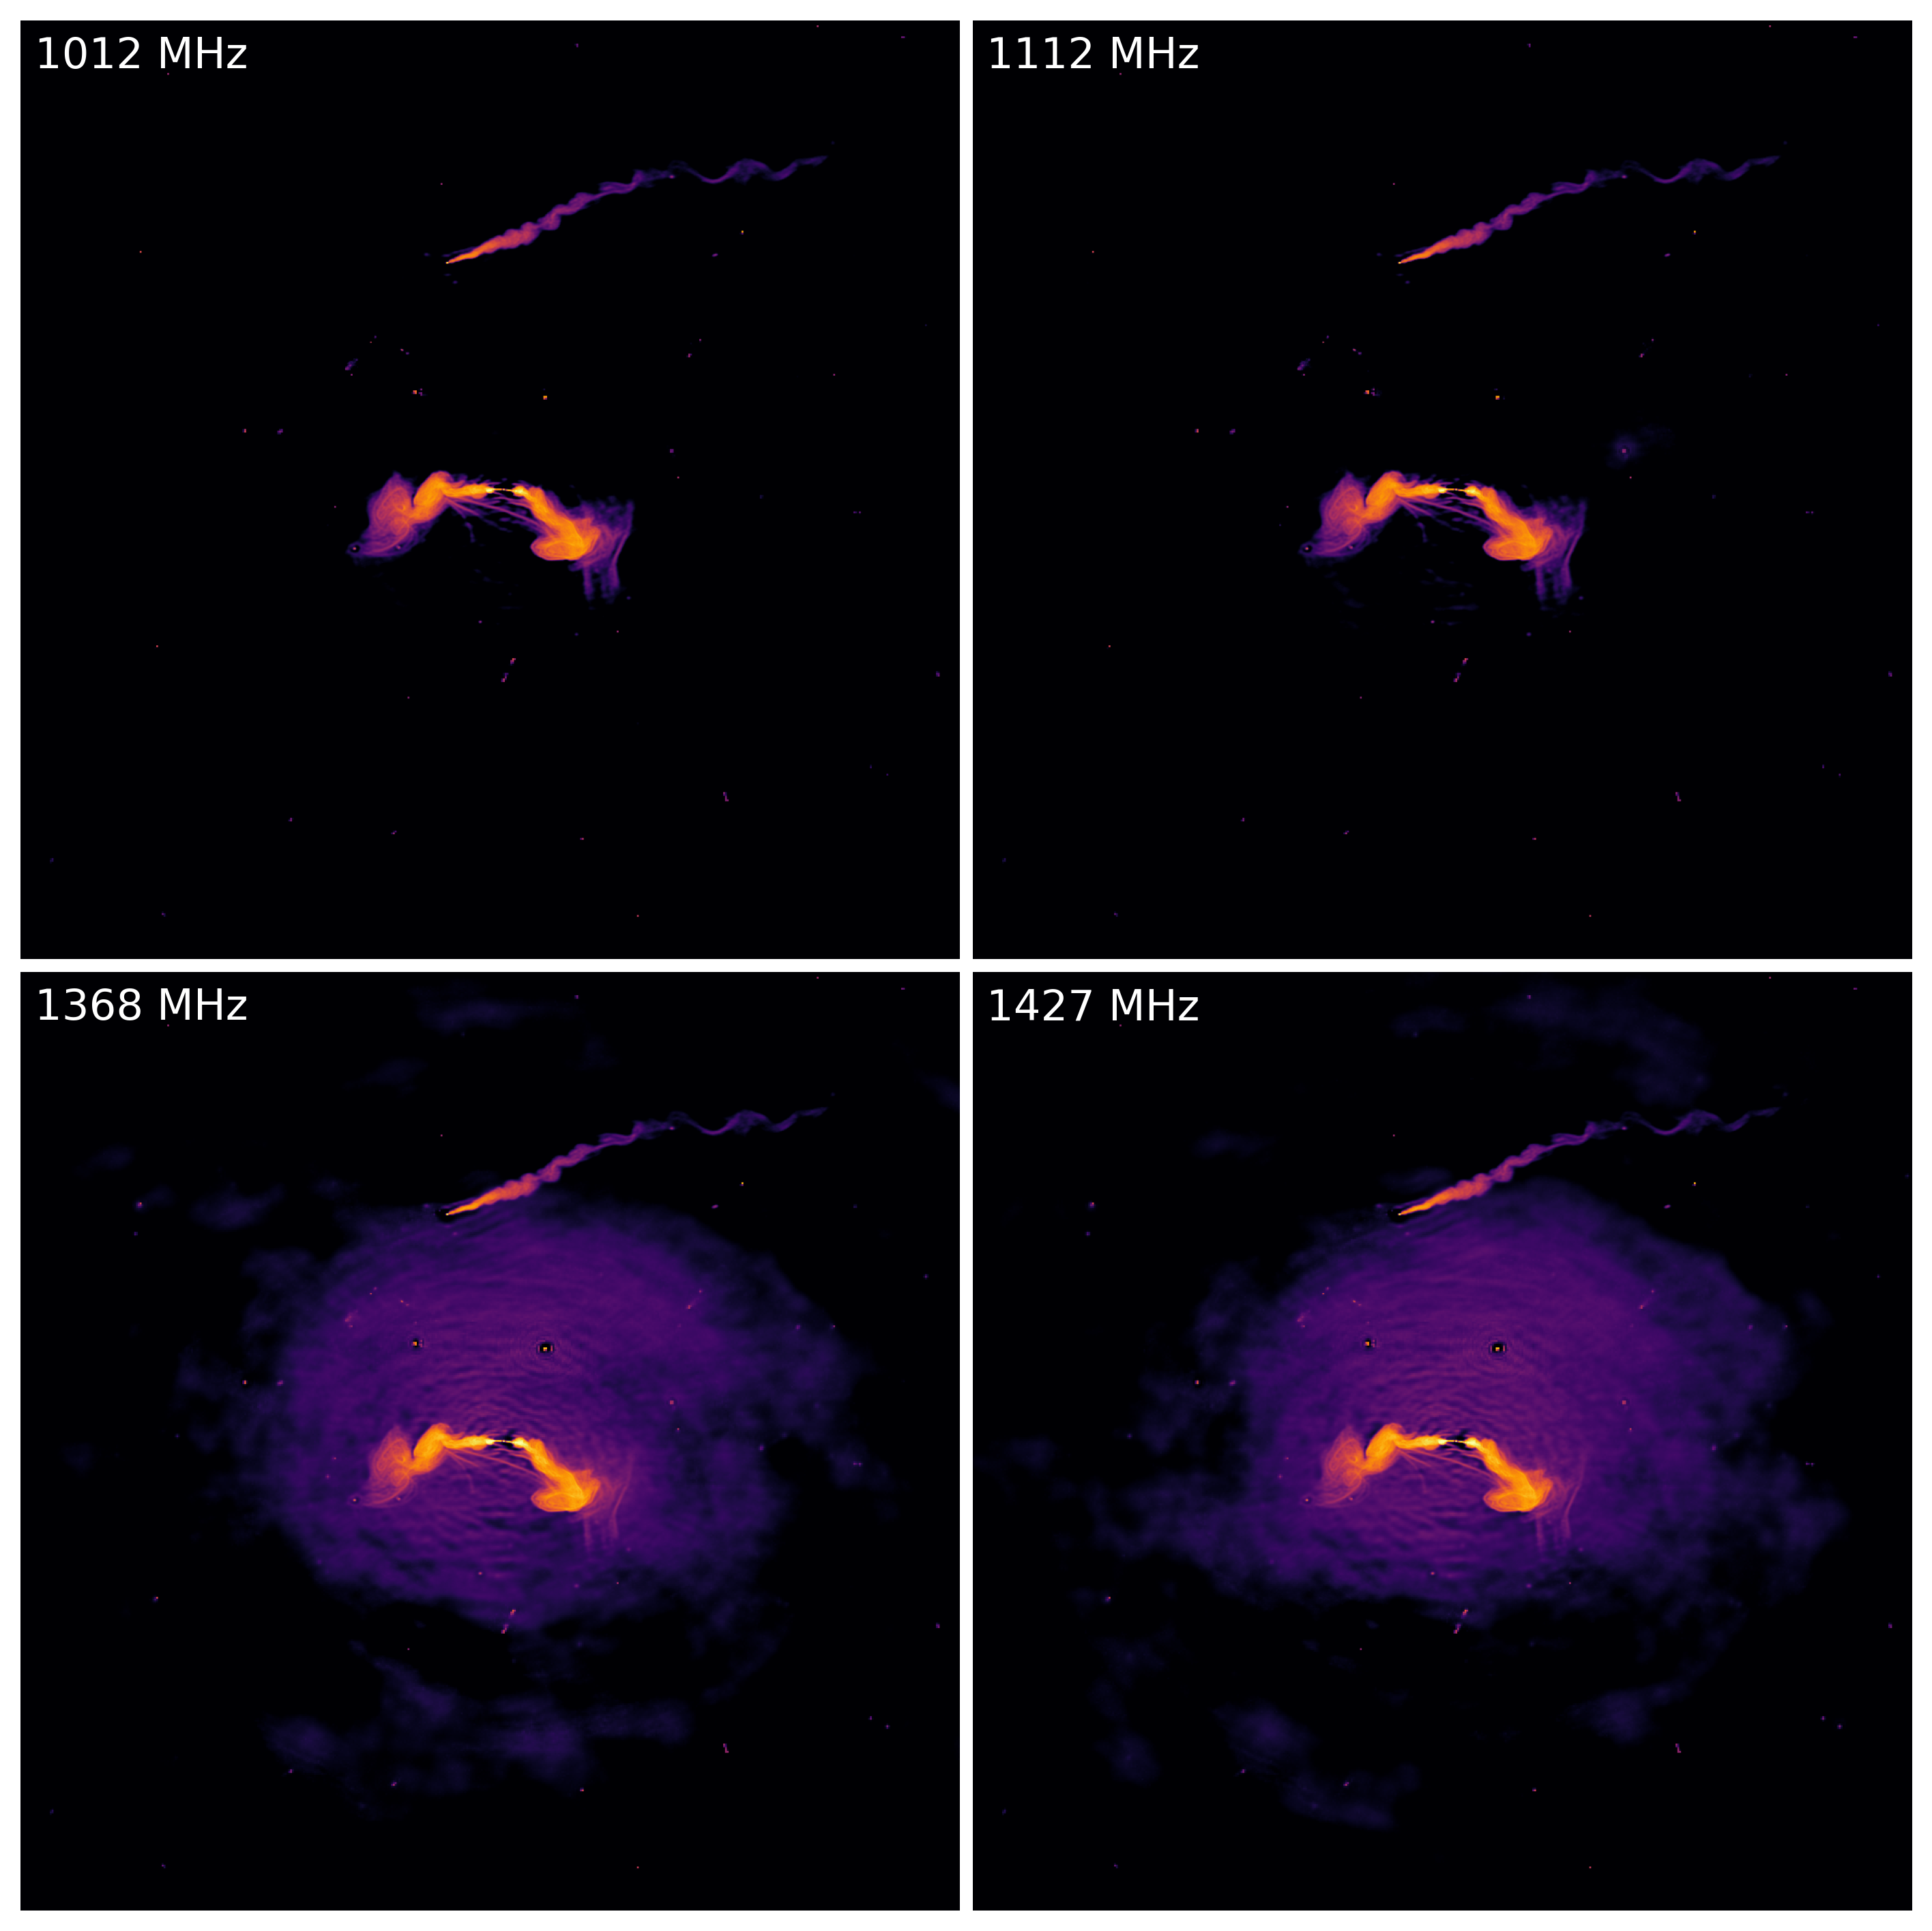

In [7]:
sky_val_mf = samples_mf.mean(sky_mf) * CONV_FACTOR
grd = sky_mf.grid
sky_val = map_signal(grd, grd.update(space=grd.spc//2))(sky_val_mf)

# mmin = 2*[2e-3] + 2*[4e-3]
# mmax = [5.5, 5.5, 11, 11]
# print(mmax)

def callback(fig, axes):
    fig.text(0.045, 0.950, '1012 MHz', fontsize=15, c='white')
    fig.text(0.51, 0.950, '1112 MHz', fontsize=15, c='white')
    fig.text(0.045, 0.485, '1368 MHz', fontsize=15, c='white')
    fig.text(0.51, 0.485, '1427 MHz', fontsize=15, c='white')

print('plotting ...')
plot_arrays(
    sky_val, 
    rows=2,
    grid_kwargs=dict(hspace=-0.71, wspace=-0.7, width_ratios=[1,1], height_ratios=[1,1]),
    callback=callback,
    **plot_dict,
)

plotting ...


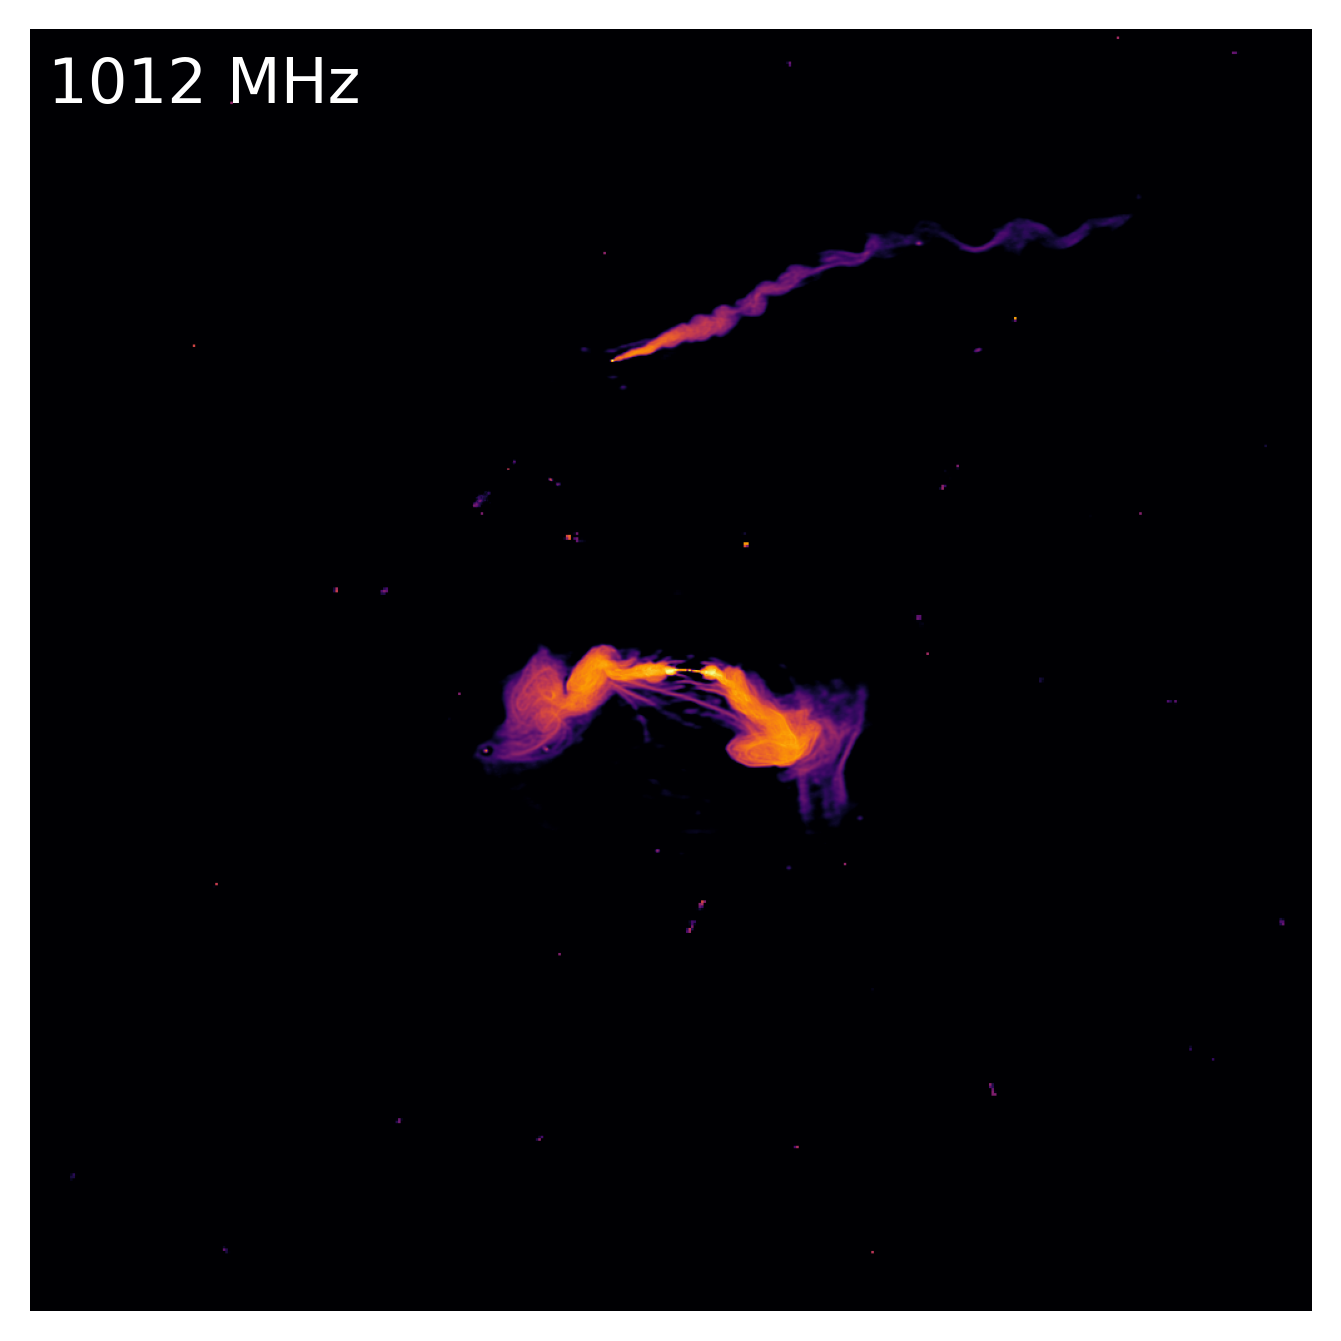

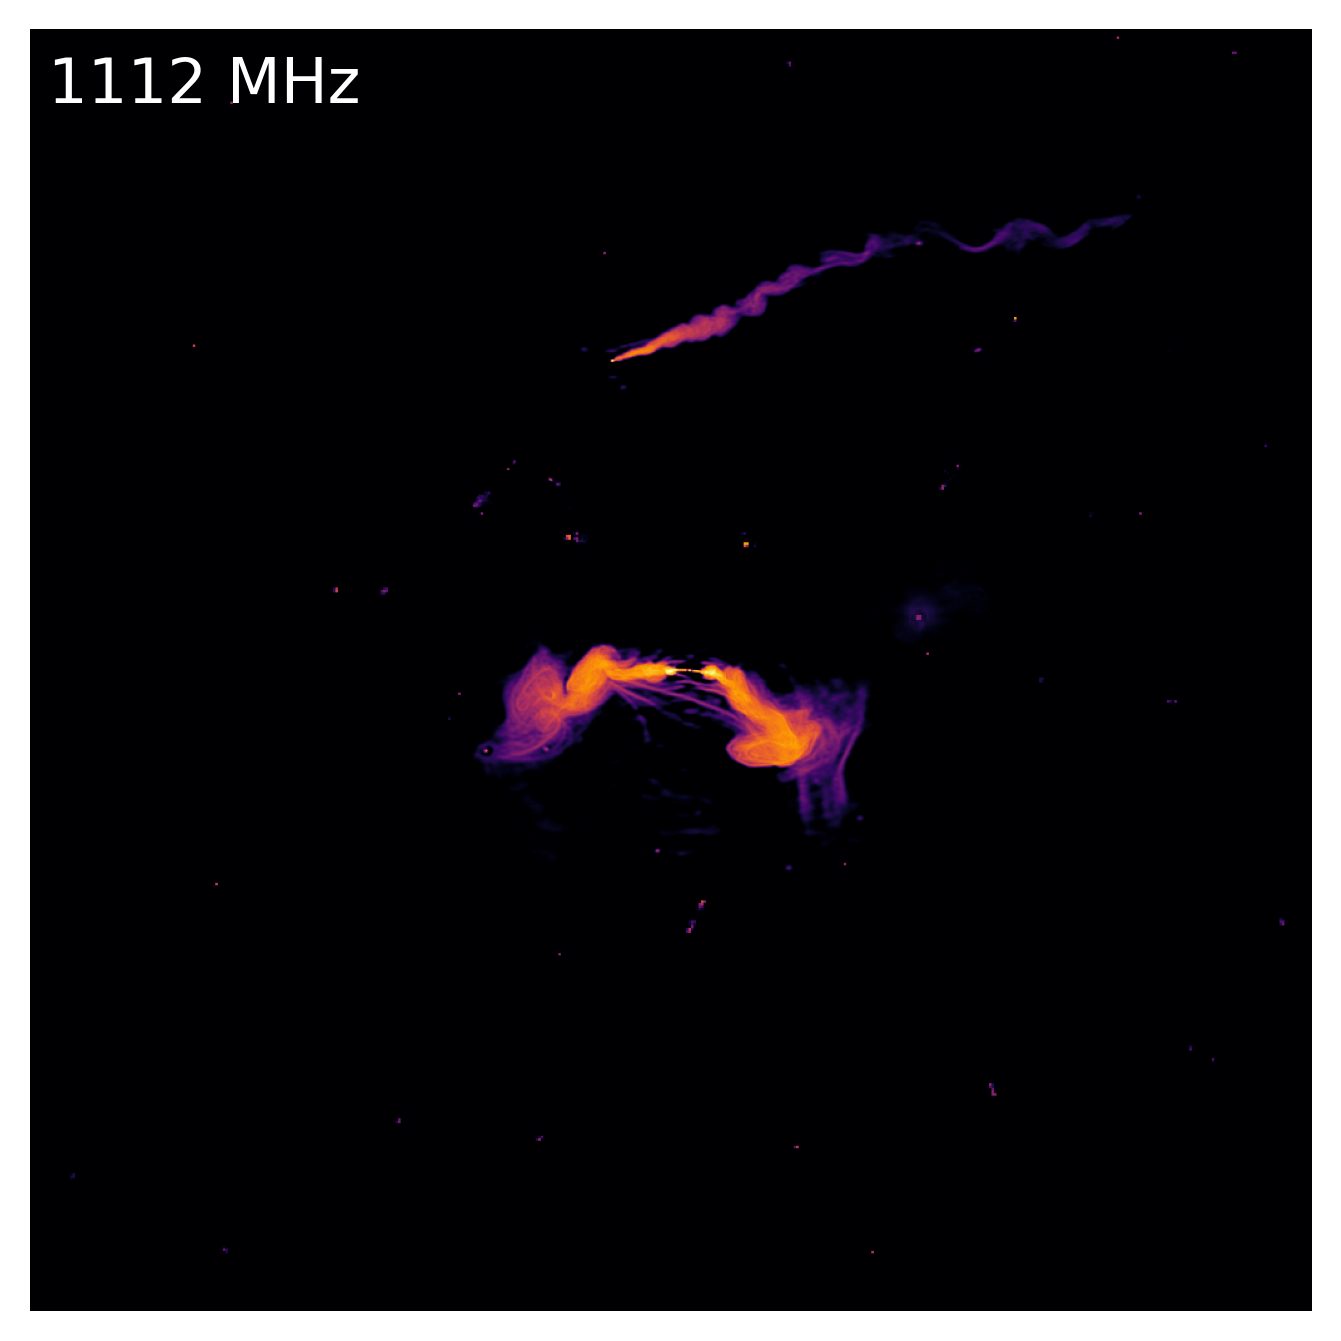

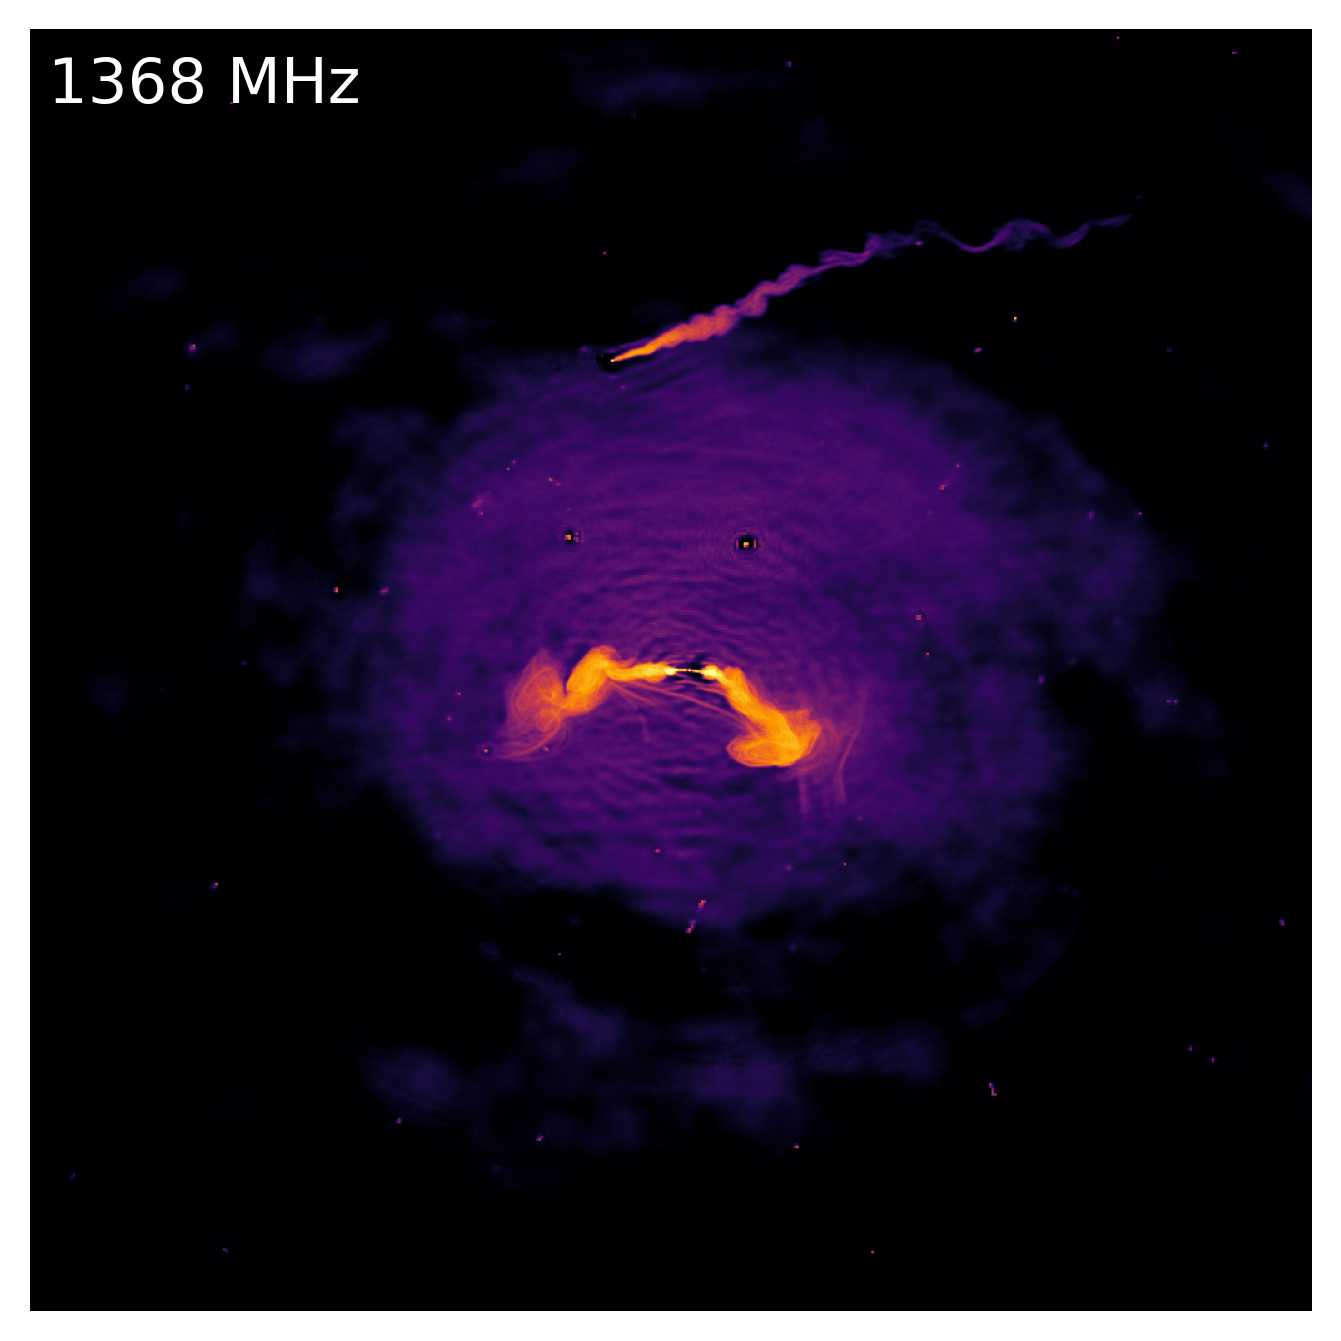

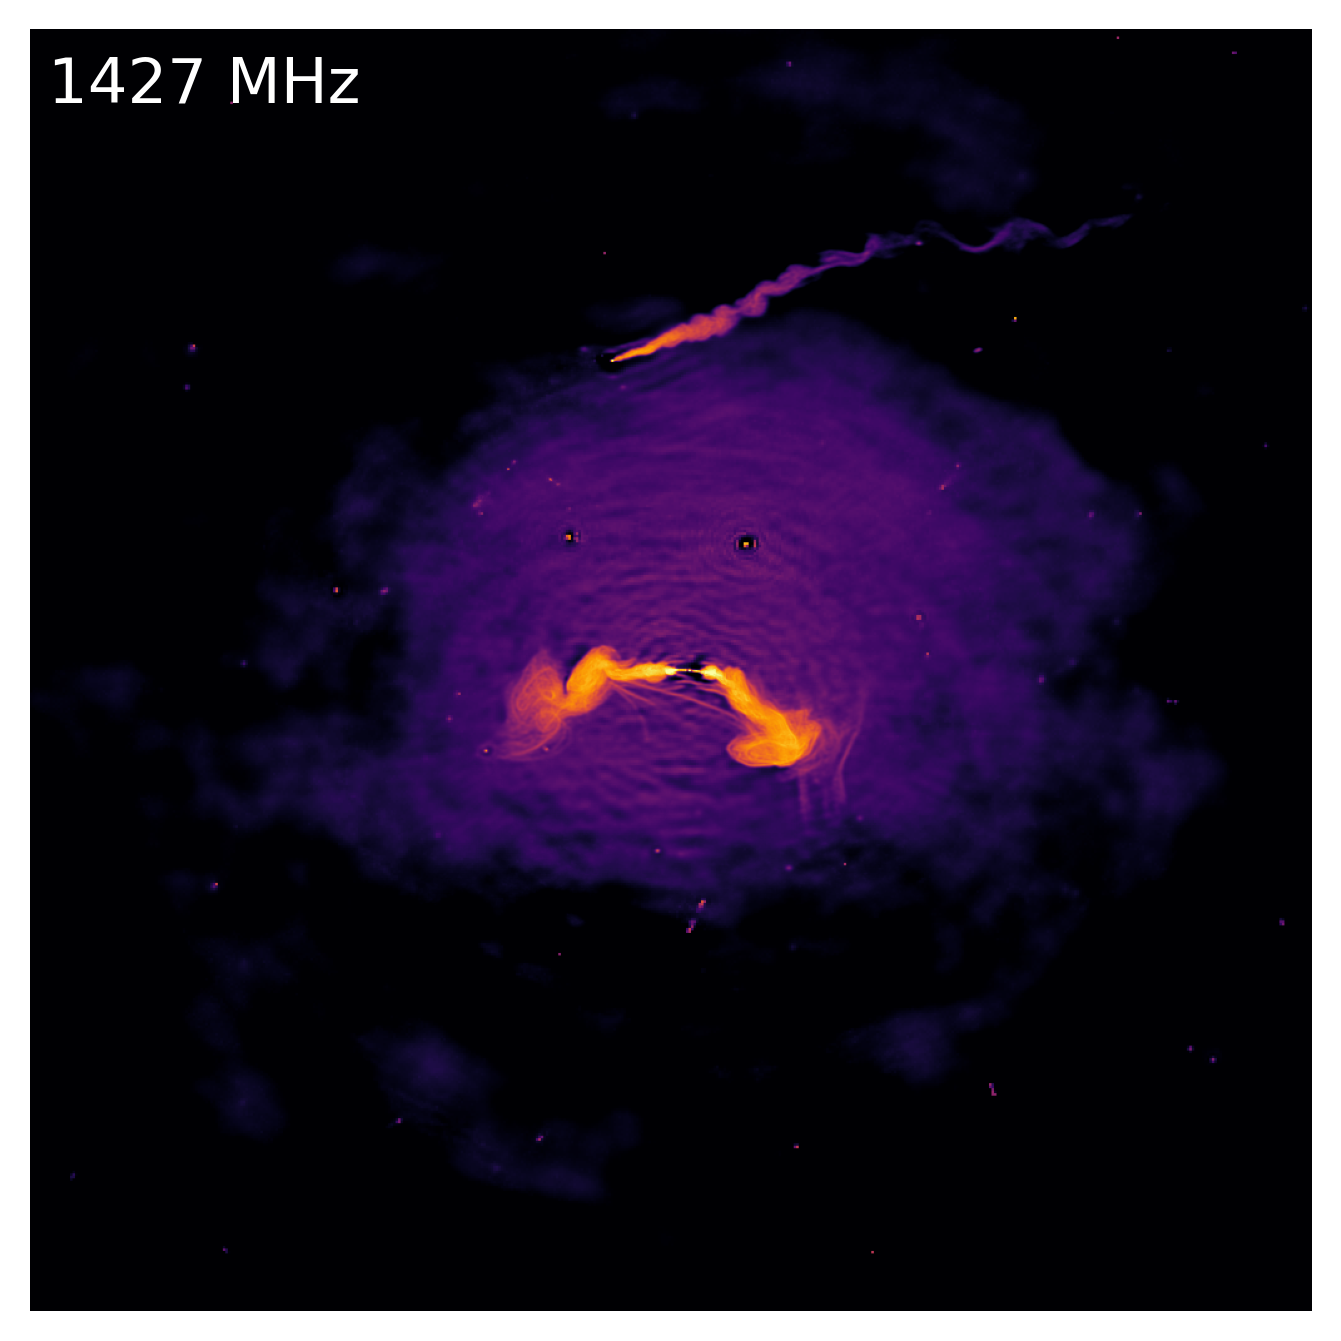

In [12]:
sky_val_mf = samples_mf.mean(sky_mf) * CONV_FACTOR
grd = sky_mf.grid
sky_val = map_signal(grd, grd.update(space=grd.spc//2))(sky_val_mf)

freq = ['1012 MHz', '1112 MHz', '1368 MHz', '1427 MHz']

print('plotting ...')
for i,f in enumerate(freq):
    plot_arrays(
        sky_val[i], 
        callback = lambda fig, ax: fig.text(0.085, 0.90, f, fontsize=15, c='white'),
        **plot_dict,
    )

plotting ...


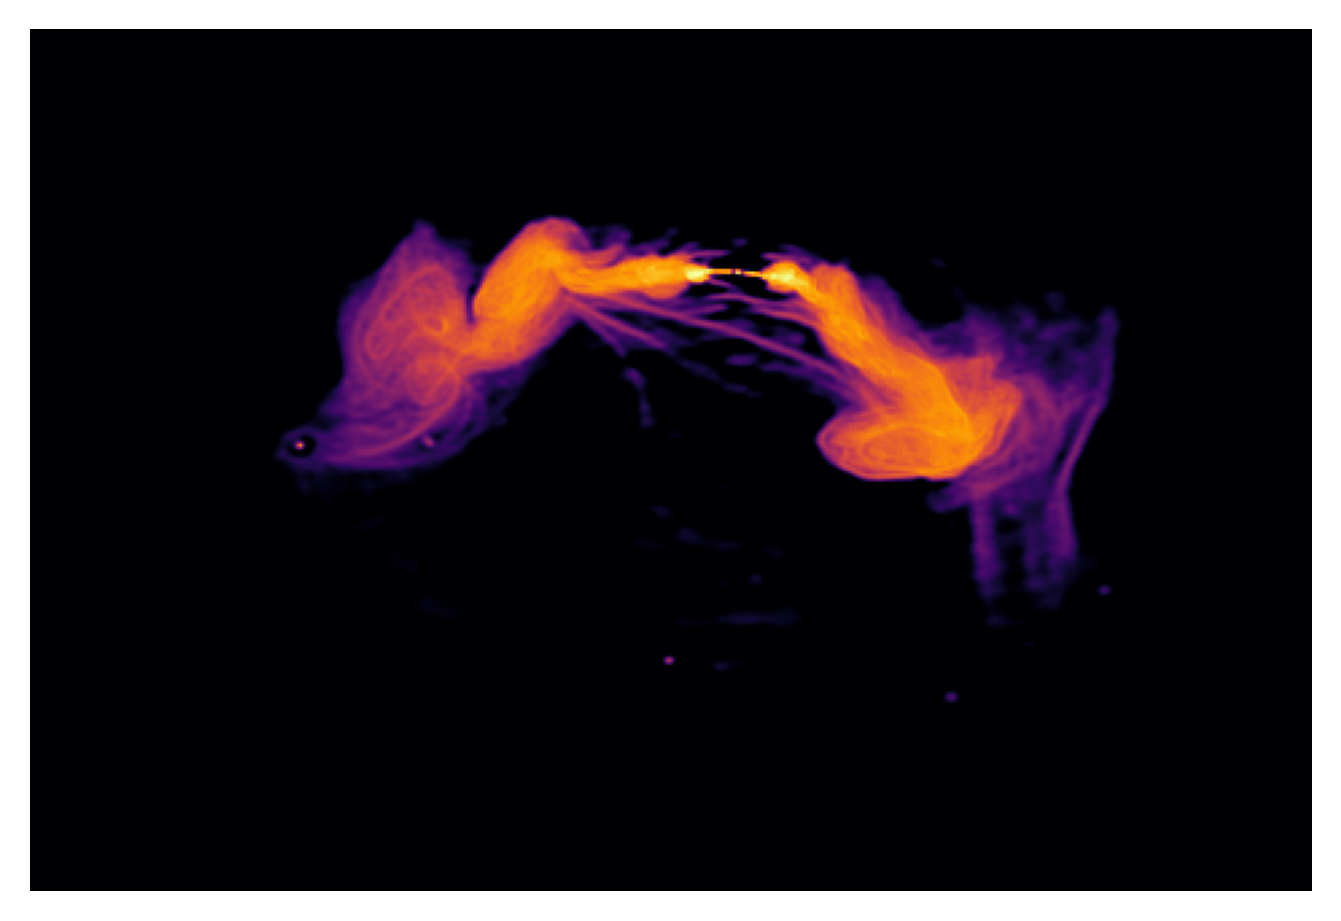

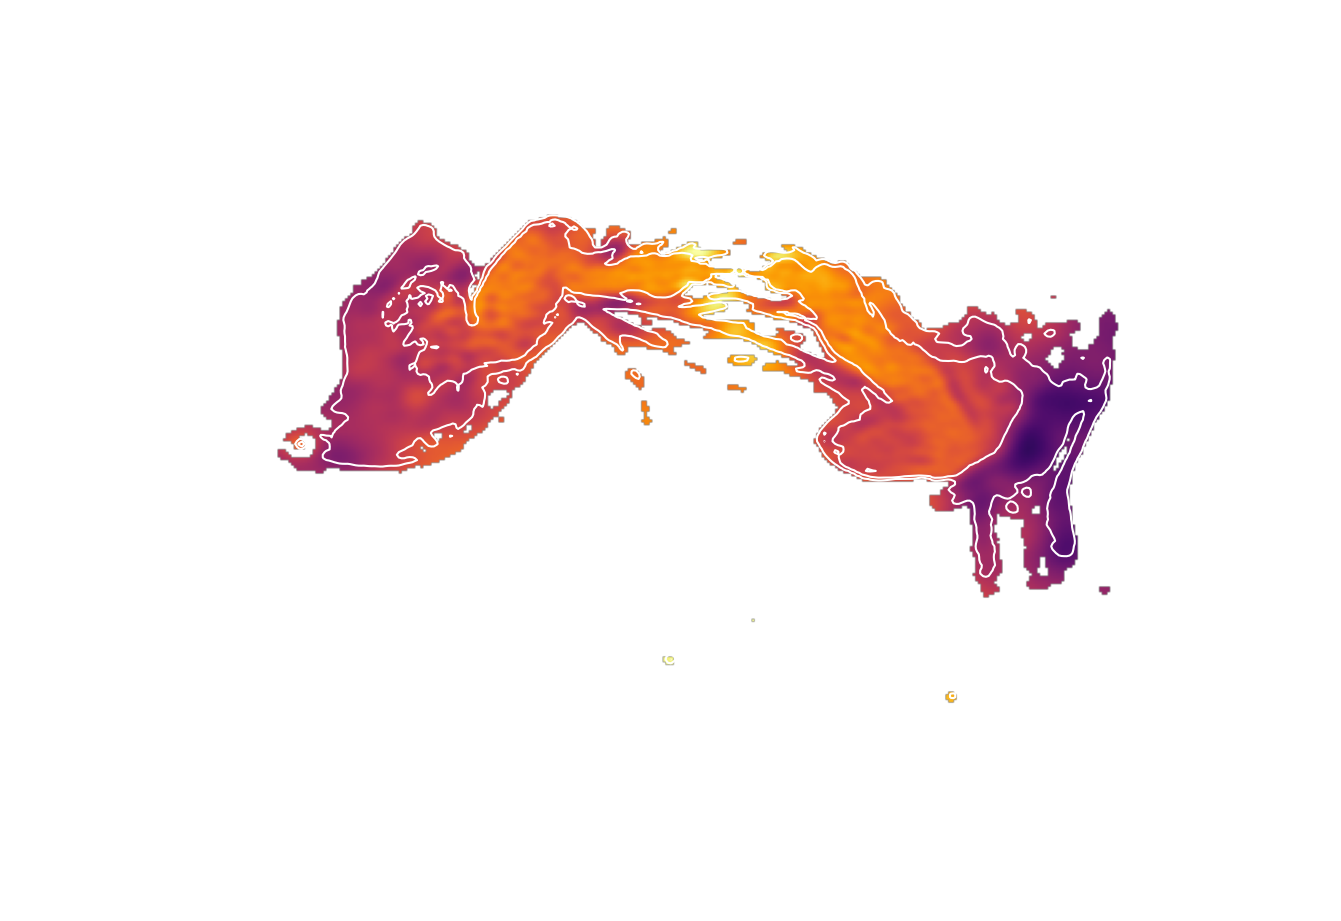

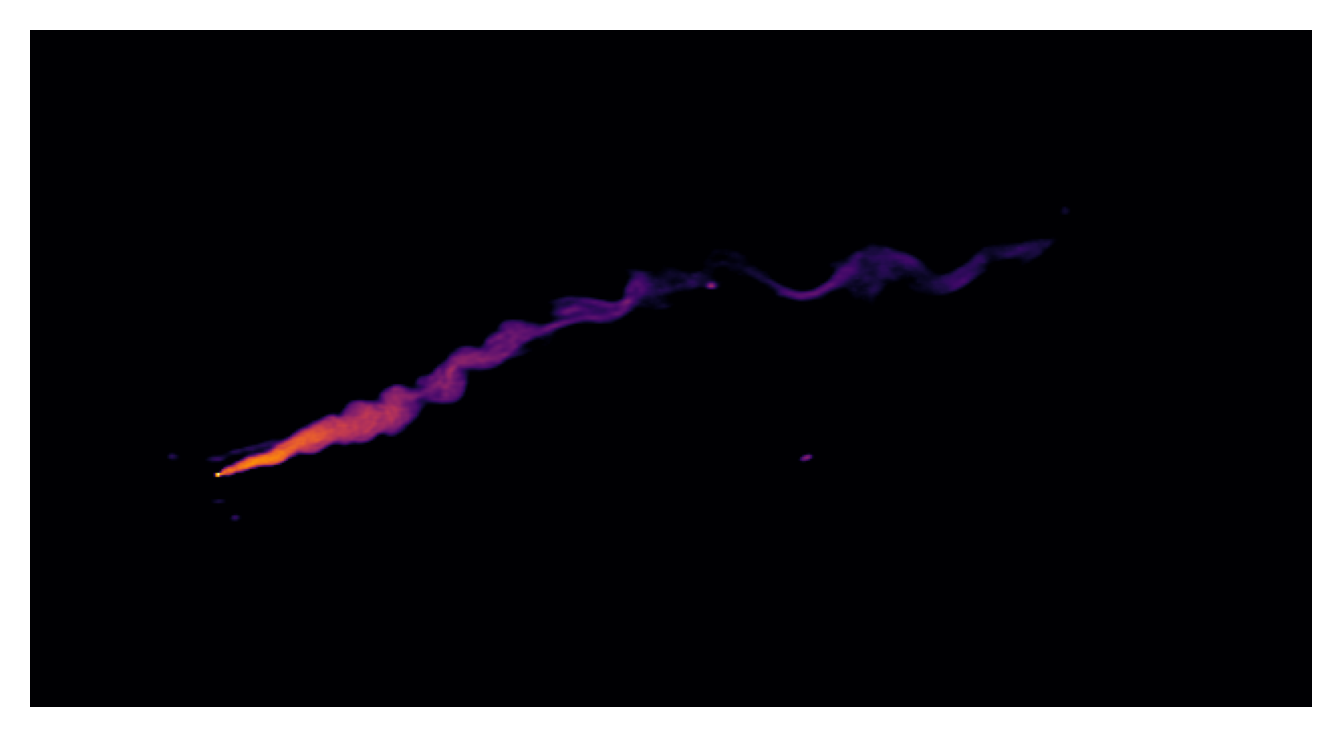

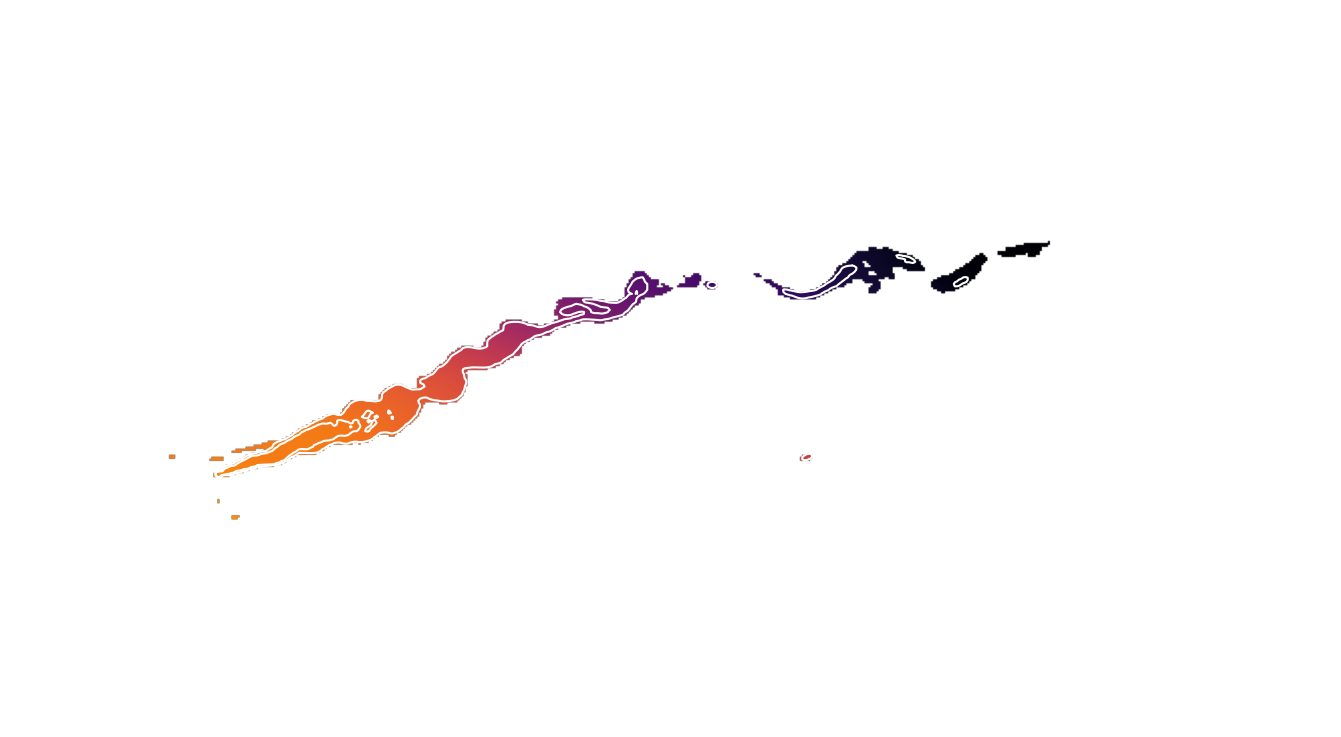

In [10]:
comps_mf = [sky_mf.objects[0], sky_mf.objects[1]]

comp_ref_mf = [samples_mf.mean(c.ref_freq_model) * CONV_FACTOR for c in comps_mf]
comp_alpha = [samples_mf.mean(c.spectral_index) for c in comps_mf]
min_cs, min_ca = 2.5e-3, 5e-3

    
print('plotting ...')
for c,a in zip(comp_ref_mf, comp_alpha):
    a = np.where(c > min_ca, a, np.nan)
    contours = {'array': c, 'colors': 'white', 'levels': [1e-2, 1e-1], 'linewidths': 0.5}
    plot_arrays(
        array = c, 
        **plot_dict | dict(vmin=min_cs),
    )
    plot_arrays(
        array = a,
        contour=contours,
        **plot_dict | dict(vmin=-1, vmax=3, norm='linear'),
    )